# 02 · Agente baseline: decidir y dejar rastro

**Objetivo.** Construir el primer agente sobre 12 informes 10-K locales: NVDA, MSFT, AAPL, GOOGL, META y AMZN, FY2024–FY2025. Convierte una pregunta en herramientas y termina siempre en una respuesta estructurada.

Se ejecuta sin clave. La API es opcional y nunca se guarda un secreto. Esto es un **baseline**: aún no incluye golden set, retrieval híbrido ni guardrails.

In [1]:
import sys, pathlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p/'pyproject.toml').exists())
sys.path.insert(0, str(RAIZ/'src'))
import matplotlib.pyplot as plt, pandas as pd
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from agente10k import agente, config
from agente10k.herramientas import TOOLS
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Modelo fijo: {config.MODELO_ID} | temperatura={config.TEMPERATURA}')

Modelo fijo: openrouter:google/gemini-3.8-flash | temperatura=0


## 1. Un ciclo de investigación, no una búsqueda única

**Qué hace la visual.** Resume el ciclo ReAct: el modelo interpreta, consulta una herramienta, lee la observación y puede volver a investigar.

**Cómo leerlo.** Una respuesta buena tiene que seguir el camino correcto: una cifra reportada pasa por XBRL; una explicación pasa por el texto. El baseline aún no corrige sus decisiones automáticamente.

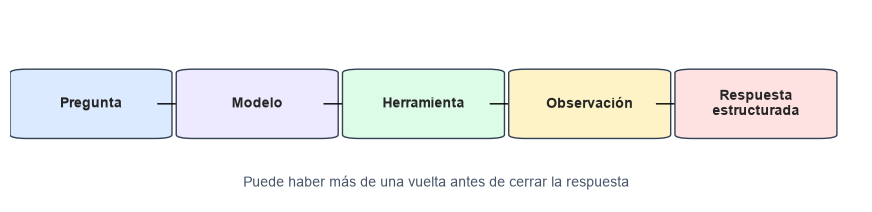

In [2]:
fig,ax=plt.subplots(figsize=(11,2.5)); ax.axis('off')
pasos=[('Pregunta','#dbeafe'),('Modelo','#ede9fe'),('Herramienta','#dcfce7'),('Observación','#fef3c7'),('Respuesta\nestructurada','#fee2e2')]
for i,(t,c) in enumerate(pasos):
 x=.02+i*.195; ax.add_patch(FancyBboxPatch((x,.35),.15,.32,boxstyle='round,pad=.02',fc=c,ec='#334155')); ax.text(x+.075,.51,t,ha='center',va='center',weight='bold')
 if i<4: ax.add_patch(FancyArrowPatch((x+.15,.51),(x+.19,.51),arrowstyle='->',mutation_scale=13))
ax.text(.5,.08,'Puede haber más de una vuelta antes de cerrar la respuesta',ha='center',color='#475569'); plt.show()

## 2. El contrato hace la respuesta comprobable

`RespuestaFinanciera` mantiene ocho campos obligatorios de contrato. `cifra` es el valor XBRL **sin escalar**; `fuente='ninguna'` significa que el corpus no contiene el dato, nunca que sea cero. Una cita textual se puede rastrear con `chunk_id`.

La celda crea dos ejemplos locales: una cifra y un hueco. No llama al modelo.

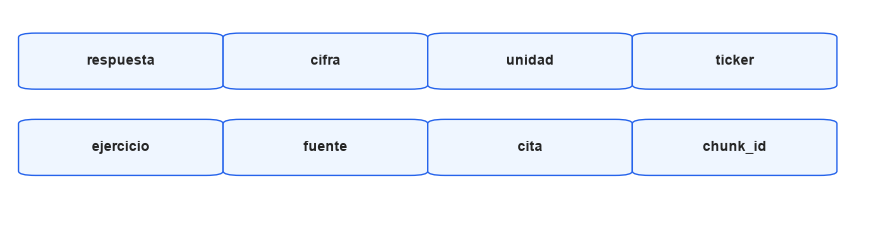

{'respuesta': 'Dato XBRL.', 'cifra': 60922000000.0, 'unidad': 'USD', 'ticker': 'NVDA', 'ejercicio': 2024, 'fuente': 'xbrl'}
{'respuesta': 'No reportado.', 'fuente': 'ninguna'}


In [3]:
campos=list(agente.RespuestaFinanciera.model_fields)[:8]
fig,ax=plt.subplots(figsize=(11,2.8)); ax.axis('off')
for i,campo in enumerate(campos):
 fila,col=divmod(i,4); x,y=.03+col*.24,.65-fila*.4; ax.add_patch(FancyBboxPatch((x,y),.2,.22,boxstyle='round,pad=.02',fc='#eff6ff',ec='#2563eb')); ax.text(x+.1,y+.11,campo,ha='center',va='center',weight='bold')
plt.show()
numero=agente.RespuestaFinanciera(respuesta='Dato XBRL.',cifra=60922000000,unidad='USD',ticker='NVDA',ejercicio=2024,fuente='xbrl')
hueco=agente.RespuestaFinanciera(respuesta='No reportado.',fuente='ninguna')
print(numero.model_dump(exclude_none=True)); print(hueco.model_dump(exclude_none=True))

## 3. Elegir la herramienta correcta

**Regla.** Cifra exacta → `get_xbrl_fact`. Riesgo o explicación → `search_filings`, con consulta inglesa y filtros. `read_section` es el último recurso porque puede devolver mucho texto. Si no sabemos si el corpus cubre una empresa o FY, usamos `list_available`.

La escala logarítmica permite comparar costes muy distintos: una sección completa no es una opción inocente.

Pregunta,Herramienta,Tokens aprox.
Cifra,get_xbrl_fact,40
Explicación,search_filings,2000
Contexto no localizado,read_section,35000
Cobertura,list_available,350


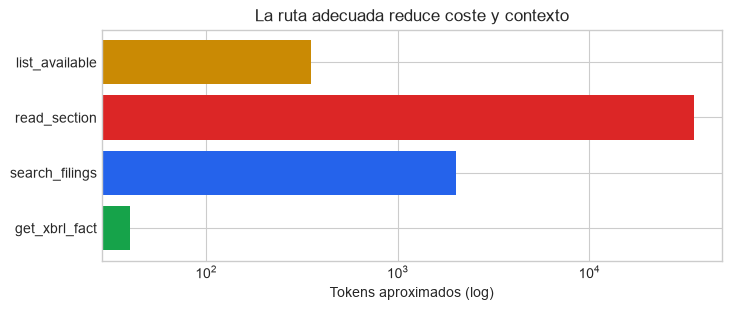

Herramientas del contrato: list_available, get_xbrl_fact, search_filings, read_section


In [4]:
rutas=pd.DataFrame([['Cifra','get_xbrl_fact',40],['Explicación','search_filings',2000],['Contexto no localizado','read_section',35000],['Cobertura','list_available',350]],columns=['Pregunta','Herramienta','Tokens aprox.'])
display(rutas.style.hide(axis='index'))
fig,ax=plt.subplots(figsize=(8,3)); ax.barh(rutas.Herramienta,rutas['Tokens aprox.'],color=['#16a34a','#2563eb','#dc2626','#ca8a04']); ax.set_xscale('log'); ax.set_xlabel('Tokens aproximados (log)'); ax.set_title('La ruta adecuada reduce coste y contexto'); plt.show()
print('Herramientas del contrato:', ', '.join(t.name for t in TOOLS))

## 4. Montaje del baseline y arnés

`construir_agente('baseline')` une una instancia del modelo a temperatura 0, cuatro herramientas, `ToolStrategy(RespuestaFinanciera)` e `InMemorySaver`. El arnés `ejecutar()` añade un hilo nuevo por pregunta, límite de recursión, fallback, trayectoria, tokens, coste comunicado y latencia.

**Límite intencionado.** No hay middleware ni verificador XBRL todavía: esas mejoras se medirán después, no se esconden dentro del baseline.

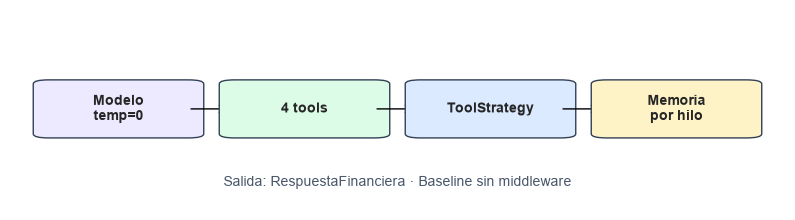

In [5]:
fig,ax=plt.subplots(figsize=(10,2.6)); ax.axis('off')
for i,(t,c) in enumerate([('Modelo\ntemp=0','#ede9fe'),('4 tools','#dcfce7'),('ToolStrategy','#dbeafe'),('Memoria\npor hilo','#fef3c7')]):
 x=.05+i*.24; ax.add_patch(FancyBboxPatch((x,.38),.18,.25,boxstyle='round,pad=.02',fc=c,ec='#334155')); ax.text(x+.09,.505,t,ha='center',va='center',weight='bold')
 if i<3: ax.add_patch(FancyArrowPatch((x+.18,.505),(x+.235,.505),arrowstyle='->',mutation_scale=13))
ax.text(.5,.12,'Salida: RespuestaFinanciera · Baseline sin middleware',ha='center',color='#475569'); plt.show()

## 5. Una trayectoria que se puede auditar

Esta comparativa simulada ilustra la ruta esperada para MSFT FY2024–FY2025: dos cifras exactas y dos búsquedas de explicación. La herramienta sintética de salida no aparece: no es una consulta al corpus.

**Qué comprobar.** Cada llamada conserva nombre y argumentos; no se deduplica. Eso permite descubrir bucles o rutas incorrectas durante la evaluación.

Vuelta,Herramienta,Finalidad
1,get_xbrl_fact,FY2024 revenue
1,get_xbrl_fact,FY2025 revenue
2,search_filings,FY2024 Item 7
2,search_filings,FY2025 Item 7


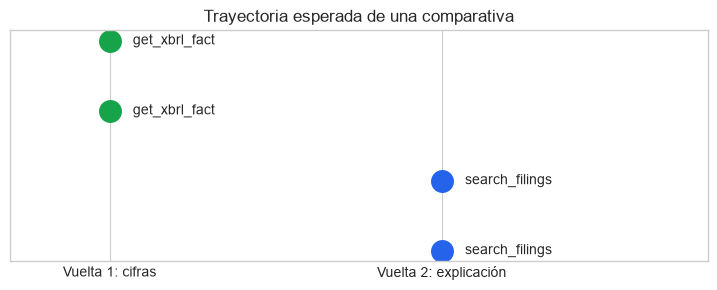

In [6]:
traza=pd.DataFrame([[1,'get_xbrl_fact','FY2024 revenue'],[1,'get_xbrl_fact','FY2025 revenue'],[2,'search_filings','FY2024 Item 7'],[2,'search_filings','FY2025 Item 7']],columns=['Vuelta','Herramienta','Finalidad'])
display(traza.style.hide(axis='index'))
fig,ax=plt.subplots(figsize=(9,3)); colores={'get_xbrl_fact':'#16a34a','search_filings':'#2563eb'}
for i,r in traza.iterrows(): ax.scatter(r.Vuelta,3-i,s=240,color=colores[r.Herramienta]); ax.text(r.Vuelta+.07,3-i,r.Herramienta,va='center')
ax.set(xticks=[1,2],xticklabels=['Vuelta 1: cifras','Vuelta 2: explicación'],yticks=[],xlim=(.7,2.8),title='Trayectoria esperada de una comparativa'); plt.show()

## 6. Prueba real opcional y cuatro límites

Con `EJECUTAR_API=False` no se hace ninguna llamada. Si se activa tras autorizar una clave, se ejecuta una sola comparativa y se imprimen salida, trayectoria y métricas. La tabla resume qué debe hacer el agente ante cifra, texto, hueco y dato fuera del corpus.

El siguiente notebook creará el golden set para medir si esta expectativa se cumple en muchas preguntas.

Caso,Ruta esperada,Fuente
Revenue NVDA FY2024,get_xbrl_fact,xbrl
Riesgo IA MSFT,search_filings,texto
Gross profit AMZN,get_xbrl_fact,ninguna
Revenue TSLA,list_available,ninguna


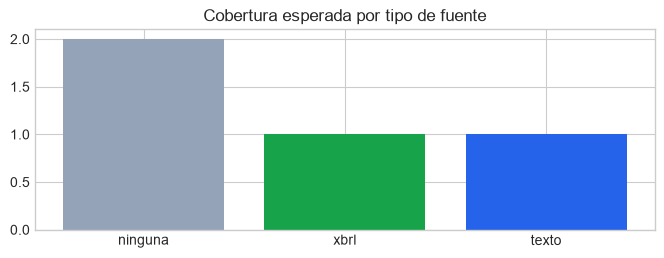

Modo local: API apagada; los ejemplos anteriores siguen siendo reproducibles.


In [7]:
EJECUTAR_API=False
casos=pd.DataFrame([['Revenue NVDA FY2024','get_xbrl_fact','xbrl'],['Riesgo IA MSFT','search_filings','texto'],['Gross profit AMZN','get_xbrl_fact','ninguna'],['Revenue TSLA','list_available','ninguna']],columns=['Caso','Ruta esperada','Fuente'])
display(casos.style.hide(axis='index'))
fig,ax=plt.subplots(figsize=(8,2.6)); ax.bar(casos.Fuente.value_counts().index,casos.Fuente.value_counts().values,color=['#94a3b8','#16a34a','#2563eb']); ax.set_title('Cobertura esperada por tipo de fuente'); plt.show()
if EJECUTAR_API:
 assert config.cargar_clave(), 'Falta OPENROUTER_API_KEY fuera del notebook.'
 real=agente.ejecutar('¿Cuánto creció el revenue de Microsoft entre FY2024 y FY2025 y a qué lo atribuye la dirección?')
 display(pd.DataFrame([real['respuesta'].model_dump(exclude_none=True)])); display(pd.DataFrame(real['tool_calls']))
else: print('Modo local: API apagada; los ejemplos anteriores siguen siendo reproducibles.')

## 7. Comprobación sin red

Estas pruebas verifican contrato, fallback, hilo nuevo y trayectoria sin API. Verde significa que el arnés es estable; no sustituye a medir la calidad financiera con el golden set.

In [8]:
import pytest
estado=pytest.main(['-q', str(RAIZ/'tests'/'test_agente.py'), str(RAIZ/'tests'/'test_contratos.py'), '-p', 'no:cacheprovider'])
assert estado==0
print('✓ Contrato y arnés comprobados sin red.')

.

.

.

.

.

...

.

.

                                                                [100%]


============================== warnings summary ===============================
..\..\..\..\..\..\..\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345
  C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; anyio
    self._mark_plugins_for_rewrite(hook, disable_autoload)

..\..\..\..\..\..\..\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345
  C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; langsmith
    self._mark_plugins_for_rewrite(hook, disable_autoload)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
9 passed, 2 warnings in 0.05s


✓ Contrato y arnés comprobados sin red.


## En una frase

El baseline ya decide una ruta, deja evidencia de sus llamadas y sabe abstenerse; ahora toca medir cuántas veces lo hace correctamente.